<a href="https://colab.research.google.com/github/mrbedoya/ml-2026/blob/main/01_Preparaci%C3%B3nDataset01Regresion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Preparación del dataset de ventas de vehículos

## 1. Librerias y configuraciones previas


In [1]:
# Tratamiento de datos
# ==============================================================================
import pandas as pd
import numpy as np

# Preparación de datos
# ==============================================================================
from sklearn.model_selection import train_test_split
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.neighbors import LocalOutlierFactor

# Gráficos
# ==============================================================================
import matplotlib.pyplot as plt
from matplotlib import style
import seaborn as sns

# Interuactuar con os y solicitudes desde HTTP
# ==============================================================================
import os
import sys
import requests

# Configuración warnings
# ==============================================================================
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Parametros globales
# ==============================================================================

# URL base de GitHub para el repositorio
GITHUB_BASE_URL = 'https://raw.githubusercontent.com/mrbedoya/ml-2026/main/'

# Nombres de los archivos requeridos
DATASET_FILE_NAME = '01_car details v4.csv'
UTILS_FILE_NAME = 'funciones.py'

# Nombres de los directorios para utilidades y datasets
DATASETS_PATH = 'datasets/'
UTILS_PATH = 'utils/'

# URL completa del dataset y utils en GitHub
github_dataset_url = os.path.join(GITHUB_BASE_URL, DATASETS_PATH, DATASET_FILE_NAME)
github_utils_url = os.path.join(GITHUB_BASE_URL, UTILS_PATH, UTILS_FILE_NAME)

# Rutas locales completas de datasets y utils
local_dataset_path = os.path.join(DATASETS_PATH, DATASET_FILE_NAME)
local_utils_path = os.path.join(UTILS_PATH, UTILS_FILE_NAME)

In [3]:
## Cargar datos desde Google Drive
## ==============================================================================

#from google.colab import drive

## Montar Google Drive
#drive.mount('/gdrive')

## Establece el directorio de trabajo dentro de directorio espefíficado en Google Drive
#os.chdir("/gdrive/MyDrive/01_Academia/02_Cursos/20260401_ApredinzajeAutomáticoI_UdeA/")

## Listar archivos de directorio
##!ls

In [4]:
# Funcion local para la carga de archivos
# ==============================================================================

def download_file(url, path, description):
    '''
    Descarga un archivo desde una URL y lo guarda localmente.

    Args:
        url (str): URL del archivo
        path (str): Ruta local de destino
        description (str): Descripción del archivo
    Returns:
        None
    '''
    print(f"Descargando {description} desde: {url}")

    # Realiza una solicitud HTTP GET a la URL proporcionada
    response = requests.get(url)

    # Lanza una excepción si la descarga falla (código de estado HTTP no 200)
    response.raise_for_status()

    # Abre el archivo local en modo de escritura binaria ('wb')
    with open(path, 'wb') as f:
        # Escribe el contenido binario de la respuesta HTTP en el archivo local
        f.write(response.content)

    # Imprime un mensaje confirmando que la descarga fue exitosa y la ruta de guardado
    print(f"{description} descargado exitosamente a: {path}")

In [5]:
## Configuración entorno Colab
# ==============================================================================

# Creación de directorios locales
os.makedirs(DATASETS_PATH, exist_ok=True)
os.makedirs(UTILS_PATH, exist_ok=True)

# Descarga de archivos
download_file(github_dataset_url, local_dataset_path, "dataset")
download_file(github_utils_url, local_utils_path, "funciones")

Descargando dataset desde: https://raw.githubusercontent.com/mrbedoya/ml-2026/main/datasets/01_car details v4.csv
dataset descargado exitosamente a: datasets/01_car details v4.csv
Descargando funciones desde: https://raw.githubusercontent.com/mrbedoya/ml-2026/main/utils/funciones.py
funciones descargado exitosamente a: utils/funciones.py


## 2. Funciones

In [6]:
## Funciones externas
# ==============================================================================

## Añade la ruta definida en 'UTILS_PATH' al 'sys.path' para que Python pueda encontrar módulos
sys.path.append(UTILS_PATH)

## Importa Funciones externas
from funciones import multiple_plot

## 3. Carga del dataset

Este dataset extraido de *Kaggle* (nombrado: **car details v4.csv** ) contiene información sobre **vehículos usados**, los cuales serán usados para la predicción de precios de venta, a partir de las diferentes variables.

A continuación una breve descripción de las variables:

****
    
| Campo | Descripción | Ejempo |
| :--- | :--- |:--- |
| Make | Marca  | Honda |
| Model | Modelo  | Amaze 1.2 VX i-VTEC |
| Price | Precio  | 505000 |
| Year | Año  | 2017 |
| Kilometer | Kilometraje  | 87150 |
| Fuel Type | Tipo de combustible  | Petrol |
| Transmission | Tipo de transmisión  | Manual |
| Location | Ubicación  | Pune |
| Color | Color  | Grey |
| Owner | Número de propietarios previos  | First |
| Seller Type | Tipo de vendedor  | Corporate |
| Engine | Tipo de motor  | 1198 cc |
| Max Power | Potencia máxima del motor  | 87 bhp @ 6000 rpm |
| Max Torque | Torque máximo del motor  | 109 Nm @ 4500 rpm |
| Drivetrain | Tipo de tracción  | FWD |
| Length | Longitud  | 3990 |
| Width | Anchura  | 1680 |
| Height | Altura  | 1505 |
| Seating Capacity | Capacidad de asientos  | 5 |
| Fuel Tank Capacity | Capacidad del tanque de combustible  | 35 |

    
****

    
Url origen datos: https://www.kaggle.com/datasets/nehalbirla/vehicle-dataset-from-cardekho?select=car+details+v4.csv


In [7]:
#Cargar el dataset
d = pd.read_csv(local_dataset_path)

In [8]:
d.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2059 entries, 0 to 2058
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Make                2059 non-null   object 
 1   Model               2059 non-null   object 
 2   Price               2059 non-null   int64  
 3   Year                2059 non-null   int64  
 4   Kilometer           2059 non-null   int64  
 5   Fuel Type           2059 non-null   object 
 6   Transmission        2059 non-null   object 
 7   Location            2059 non-null   object 
 8   Color               2059 non-null   object 
 9   Owner               2059 non-null   object 
 10  Seller Type         2059 non-null   object 
 11  Engine              1979 non-null   object 
 12  Max Power           1979 non-null   object 
 13  Max Torque          1979 non-null   object 
 14  Drivetrain          1923 non-null   object 
 15  Length              1995 non-null   float64
 16  Width 

In [9]:
d.head(2)

,Make,Model,Price,Year,Kilometer,Fuel Type,Transmission,Location,Color,Owner,Seller Type,Engine,Max Power,Max Torque,Drivetrain,Length,Width,Height,Seating Capacity,Fuel Tank Capacity
0,Honda,Amaze 1.2 VX i-VTEC,505000,2017,87150,Petrol,Manual,Pune,Grey,First,Corporate,1198 cc,87 bhp @ 6000 rpm,109 Nm @ 4500 rpm,FWD,3990.0,1680.0,1505.0,5.0,35.0
1,Maruti Suzuki,Swift DZire VDI,450000,2014,75000,Diesel,Manual,Ludhiana,White,Second,Individual,1248 cc,74 bhp @ 4000 rpm,190 Nm @ 2000 rpm,FWD,3995.0,1695.0,1555.0,5.0,42.0


## 4. Limpieza de datos (Data Cleaning)

In [10]:
#Borrando columnas que no se utilizarán

d.drop([ 'Model', 'Location', 'Color', 'Max Power', 'Max Torque'], axis='columns', inplace=True)

In [11]:
#Se limpia la variable Engine para convertirla en una variable numérica

#Se borra todos los valores ' cc'
d['Engine'] = d['Engine'].str.replace(' cc', '')

#se convierte a variable tipo float
d['Engine'] = d['Engine'].astype('float64')
d["Engine"].dtype

dtype('float64')

In [12]:
#Verificación y eliminación de registros duplicados

#Verificación de registros duplicados
d.loc[d.duplicated()]

,Make,Price,Year,Kilometer,Fuel Type,Transmission,Owner,Seller Type,Engine,Drivetrain,Length,Width,Height,Seating Capacity,Fuel Tank Capacity
258,BMW,2950000,2015,84700,Diesel,Automatic,Second,Individual,2993.0,AWD,4886.0,1938.0,1762.0,5.0,NaN
923,Renault,315000,2017,15507,Petrol,Manual,First,Individual,799.0,FWD,3679.0,1579.0,1478.0,5.0,28.0
1217,Maruti Suzuki,725000,2019,11874,Petrol,Automatic,First,Individual,1197.0,FWD,3840.0,1735.0,1530.0,5.0,37.0
1555,Hyundai,649000,2020,52236,Petrol,Manual,First,Individual,1197.0,FWD,3765.0,1660.0,1520.0,5.0,43.0
1603,Mercedes-Benz,7475000,2021,13000,Diesel,Automatic,First,Individual,1950.0,RWD,5063.0,1860.0,1494.0,5.0,80.0
1856,Skoda,1390000,2017,56000,Petrol,Automatic,First,Individual,1798.0,FWD,4670.0,1814.0,1476.0,5.0,50.0


In [13]:
# eliminación de registros duplicados
d = d.drop_duplicates()

#Reiniciar el indice
d.reset_index(drop=True, inplace=True)

In [14]:
# Tasa de cambio aproximada de rupias indias (INR) a dólares (USD).
# Es un valor fijo de referencia para fines didácticos; en un proyecto real se documentaría
# la fecha/fuente exacta de la tasa (p. ej. tasa de cambio al momento de la extracción del dataset).
tasa_de_cambio = 0.012

d['Price'] = d['Price'] * tasa_de_cambio

In [15]:
d.head(2)

,Make,Price,Year,Kilometer,Fuel Type,Transmission,Owner,Seller Type,Engine,Drivetrain,Length,Width,Height,Seating Capacity,Fuel Tank Capacity
0,Honda,6060.0,2017,87150,Petrol,Manual,First,Corporate,1198.0,FWD,3990.0,1680.0,1505.0,5.0,35.0
1,Maruti Suzuki,5400.0,2014,75000,Diesel,Manual,Second,Individual,1248.0,FWD,3995.0,1695.0,1555.0,5.0,42.0


## 5. Separación de datos de entrenamiento y prueba

Para evitar fuga de información (*data leakage*), separamos aquí el conjunto de entrenamiento y de prueba, **antes** de calcular cualquier estadística que se use para transformar los datos (imputación, valores atípicos, codificación de `Make` en `PriceRange`, etc.).

De aquí en adelante:
- `d` se refiere **únicamente al conjunto de entrenamiento**. Todo el análisis exploratorio y la preparación de datos que siguen (secciones 6 y 7) se ajustan solo con estos datos.
- `d_test` es el conjunto de prueba: se aparta intacto y solo se transforma al final (sección 8), reutilizando los mismos objetos/parámetros ya ajustados sobre el entrenamiento — nunca se vuelve a "ajustar" nada con datos de prueba.

In [16]:
# Se separa el conjunto de datos en entrenamiento (90%) y prueba (10%) ANTES de ajustar
# cualquier imputador, detector de atípicos o codificación, para evitar fuga de información.

d, d_test = train_test_split(d, train_size=0.90, random_state=1234)

d.reset_index(drop=True, inplace=True)
d_test.reset_index(drop=True, inplace=True)

print(f"Filas de entrenamiento: {d.shape[0]}")
print(f"Filas de prueba: {d_test.shape[0]}")

Filas de entrenamiento: 1847
Filas de prueba: 206


## 6. Visualización de datos

### Variables de entrada

In [17]:
#Lista de variables categóricas
catCols = d.select_dtypes(include = ["object", 'category']).columns.tolist()

d[catCols].head(2)

,Make,Fuel Type,Transmission,Owner,Seller Type,Drivetrain
0,Hyundai,Petrol,Manual,First,Individual,FWD
1,Hyundai,Petrol,Manual,First,Individual,FWD


In [18]:
#Lista de variables numéricas

numCols=d.select_dtypes(include = ['float64','int32','int64']).columns.tolist()
d[numCols].head()

,Price,Year,Kilometer,Engine,Length,Width,Height,Seating Capacity,Fuel Tank Capacity
0,9300.000,2020,39000,1197.0,3995.0,1775.0,1505.0,5.0,37.0
1,7500.000,2019,31000,1197.0,3985.0,1734.0,1505.0,5.0,45.0
2,33600.000,2018,20000,2143.0,4630.0,1777.0,1432.0,5.0,56.0
3,4140.000,2011,50667,NaN,NaN,NaN,NaN,NaN,NaN
4,11939.988,2016,105000,2179.0,4585.0,1890.0,1785.0,7.0,70.0


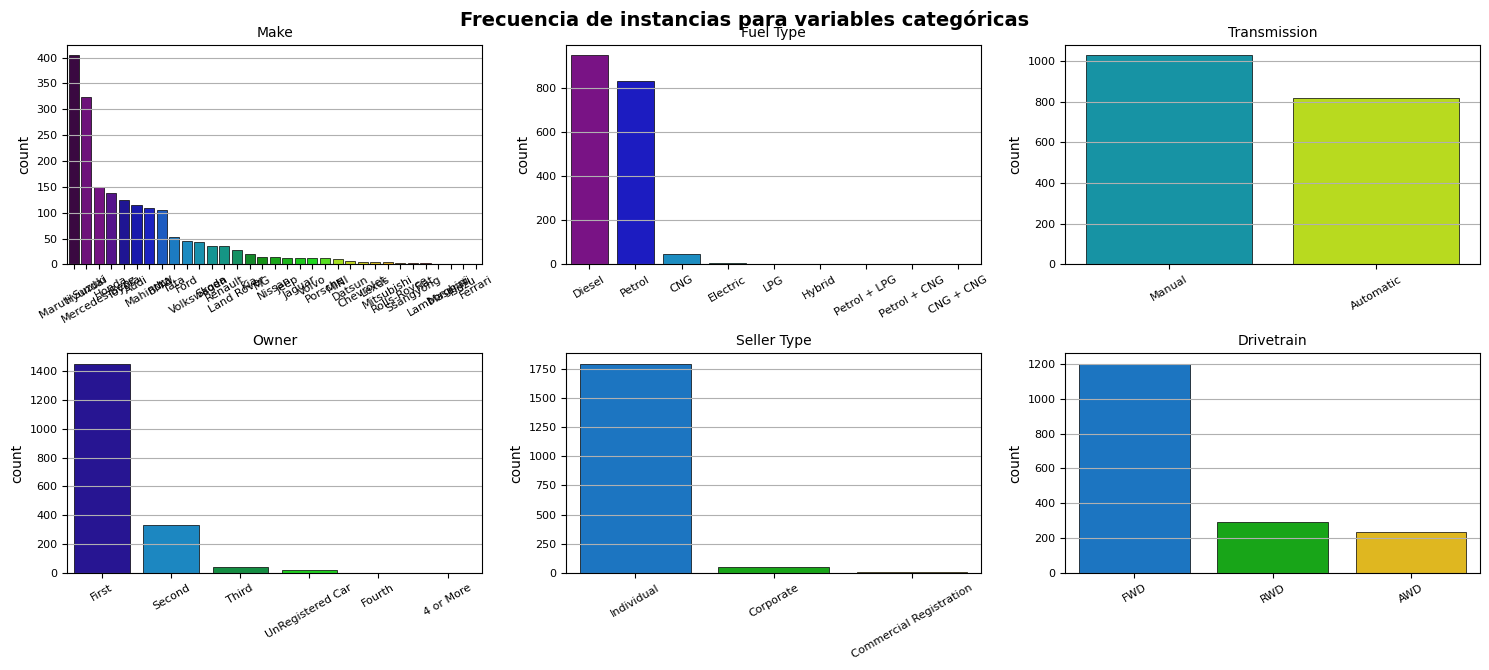

In [19]:
#Visualización de frecuencia de instancias para variables categóricas
multiple_plot(3, d , catCols, None, 'countplot', 'Frecuencia de instancias para variables categóricas',30)

In [20]:
# Distribución de cada variable categórica en el conjunto de datos

for col in catCols:
    print("="*5 + f" {col} " + "="*20)
    print(d[col].value_counts())
    print()

===== Make ====================
Make
Maruti Suzuki    404
Hyundai          323
Mercedes-Benz    150
Honda            138
Toyota           124
Audi             115
Mahindra         109
BMW              105
Tata              53
Ford              45
Volkswagen        43
Skoda             35
Renault           35
Land Rover        28
Kia               20
MG                15
Nissan            14
Jeep              13
Jaguar            13
Volvo             12
Porsche           12
MINI              10
Datsun             6
Chevrolet          5
Lexus              5
Mitsubishi         4
Rolls-Royce        3
Ssangyong          2
Fiat               2
Lamborghini        1
Maserati           1
Isuzu              1
Ferrari            1
Name: count, dtype: int64

===== Fuel Type ====================
Fuel Type
Diesel          949
Petrol          834
CNG              48
Electric          7
LPG               3
Hybrid            3
Petrol + LPG      1
Petrol + CNG      1
CNG + CNG         1
Name: count, dty

Text(0.5, 1.1, 'Distribución de la variable Make vs. el precio')

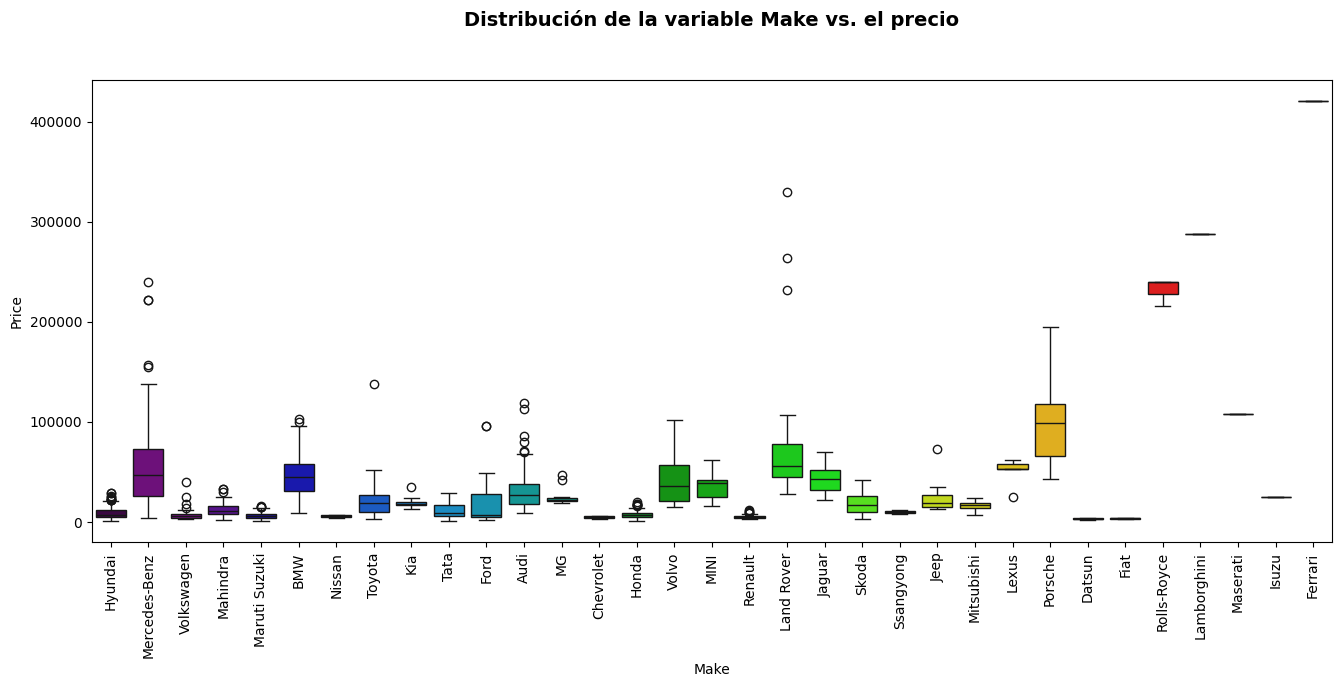

In [21]:
fig, axes = plt.subplots(1, 1, figsize=(16, 6))
ax_cond = axes
sns.boxplot(data=d,
            x='Make',
            y='Price',
            ax=axes,
            palette='nipy_spectral',
            zorder=1
            )
# Personalizar el eje x
ax_cond.set_xticklabels(ax_cond.get_xticklabels(), rotation=90)
# Configurar título
ax_cond.set_title('Distribución de la variable Make vs. el precio', fontsize=14, fontweight="bold", y=1.1)

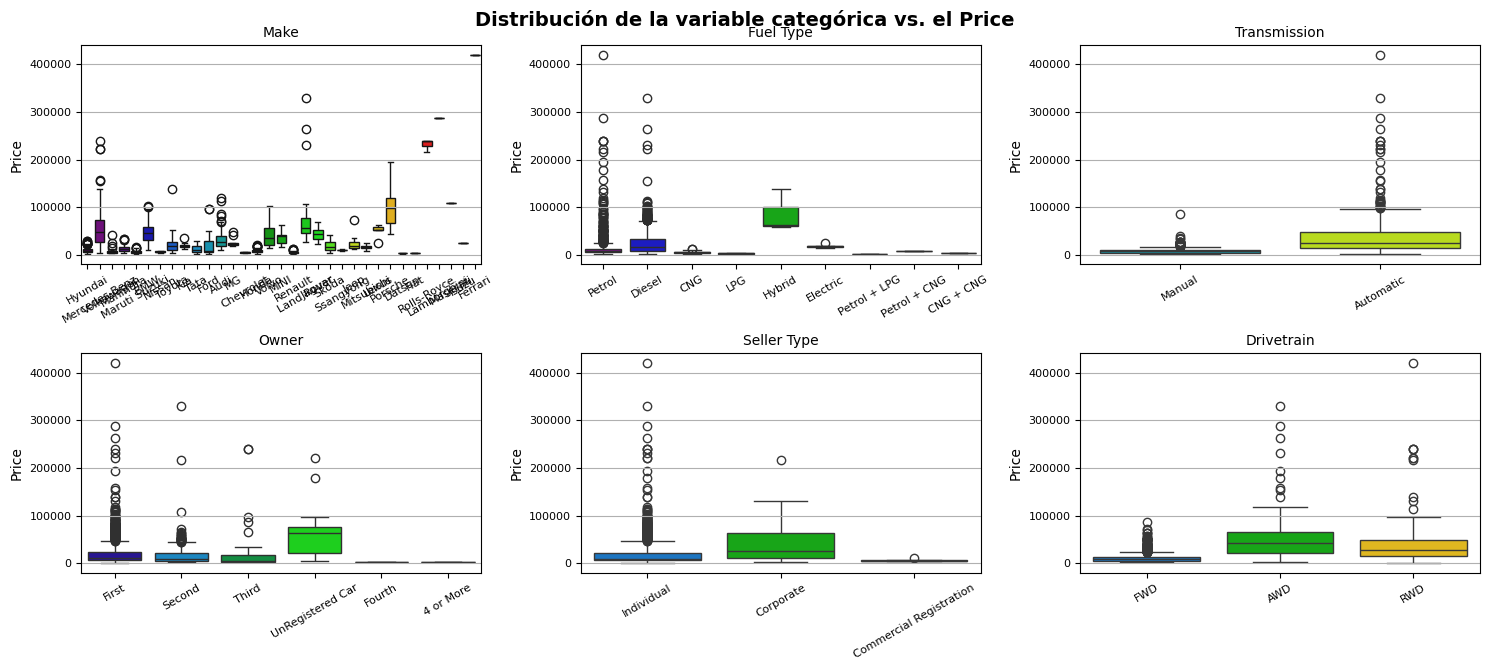

In [22]:
multiple_plot(3, d , catCols, 'Price', 'boxplot', 'Distribución de la variable categórica vs. el Price',30)

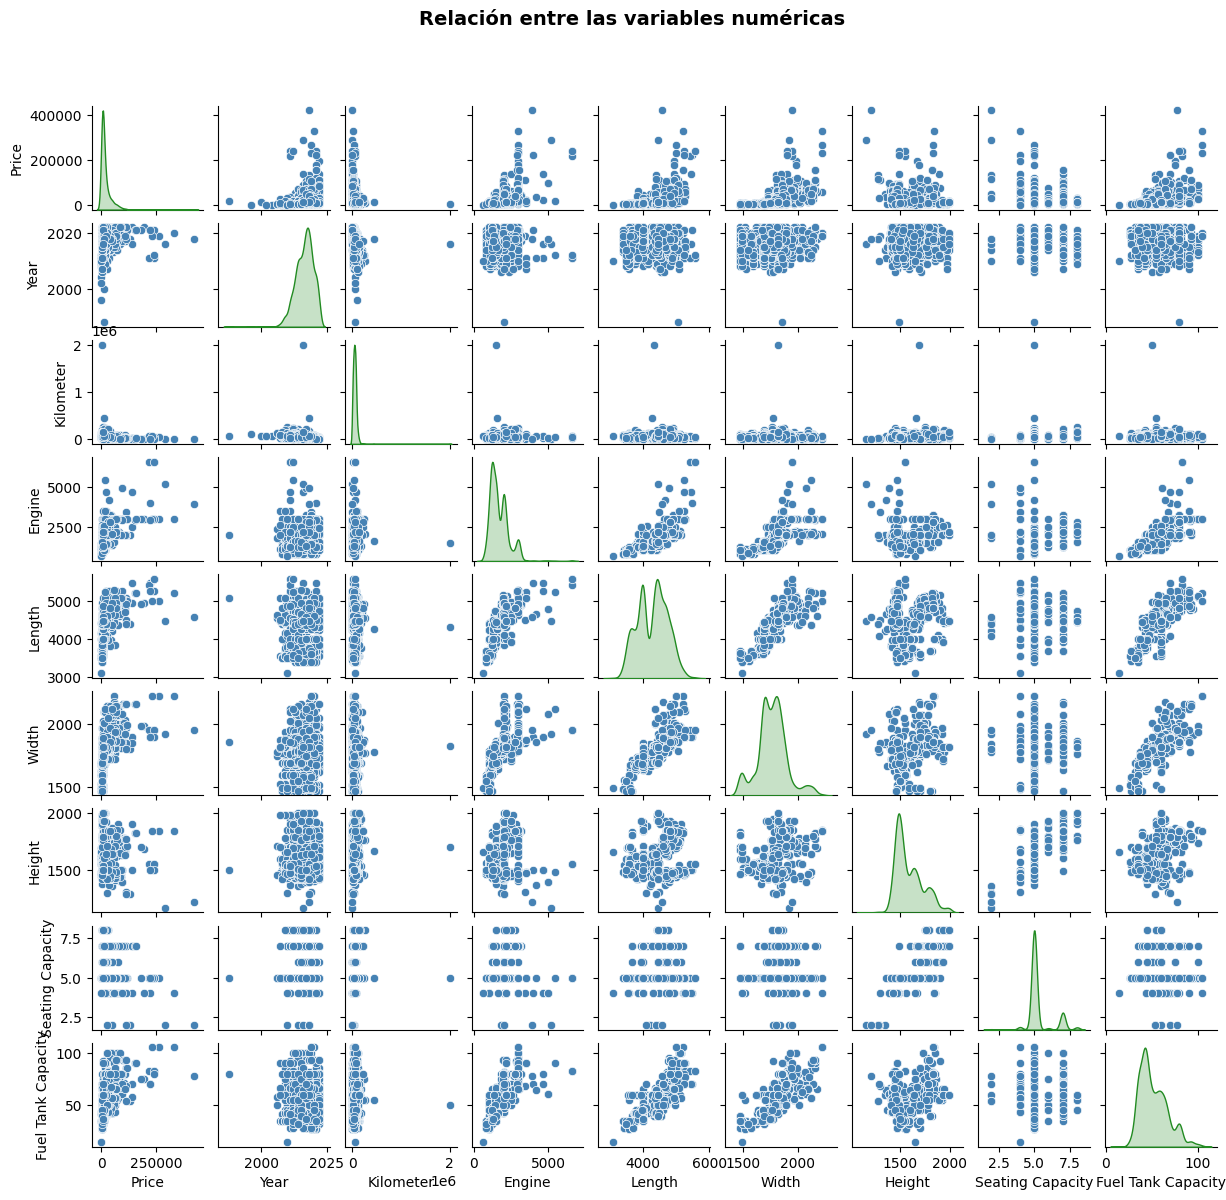

In [23]:
#Visualización de variables numéricas con respecto al precio
multiple_plot(1, d , numCols, None, 'scatterplot', 'Relación entre las variables numéricas',30)

### Variable de salida

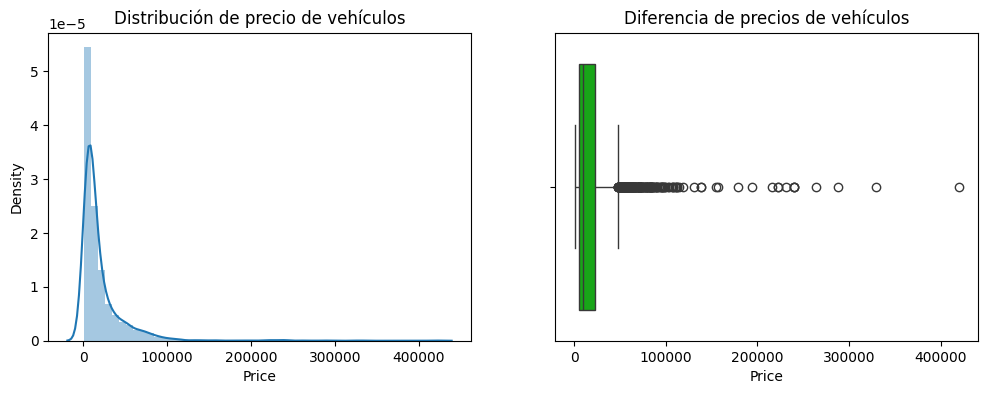

In [24]:
#Histográma y caja de bigotes del precio de los vehículos

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.title('Distribución de precio de vehículos')
sns.distplot(d['Price'])

plt.subplot(1,2,2)
plt.title('Diferencia de precios de vehículos')
sns.boxplot(x=d['Price'], palette='nipy_spectral')

plt.show()

In [25]:
#Descripción del precio de los vehículos: Total, media, desviación, mínimo, máximo y percentiles

#Configuración de formato de visualización
pd.set_option('display.float_format', lambda x: '%.0f' % x)

#Descripción
print(d['Price'].describe(percentiles = [0.25,0.50,0.75,0.85,0.90,0.95,0.975,1]))

count     1847
mean     20297
std      29249
min        588
25%       5820
50%       9900
75%      22500
85%      37092
90%      50304
95%      70060
97.5%    86400
100%    420000
max     420000
Name: Price, dtype: float64


## 7. Preparación de datos

### Valores atípicos de la variable de salida

In [26]:
#Calculo de valores atípicos


#Calculo de Q1 t Q3
Q1 = np.percentile(d['Price'], 25, interpolation = 'midpoint')
Q3 = np.percentile(d['Price'], 75, interpolation = 'midpoint')

#Cálculo del rango intercuartil
IQR = Q3 - Q1

#Cálculo de valor mínimo y máximo para los valores atípicos
VAInf = Q1 - 1.5*IQR
VASup = Q3 + 1.5*IQR

print(f'Valor atípico leve inferior:{VAInf}')
print(f'Valor atípico leve superior:{VASup}')


Valor atípico leve inferior:-19200.029999999995
Valor atípico leve superior:47520.018


In [27]:
# Se eliminan los valores atípicos
d = d.drop(d[d['Price']>VASup].index)

#Reiniciar el indice
d.reset_index(drop=True, inplace=True)

print(f"Filas después de eliminar atípicos de Price: {d.shape[0]}")

Filas después de eliminar atípicos de Price: 1645


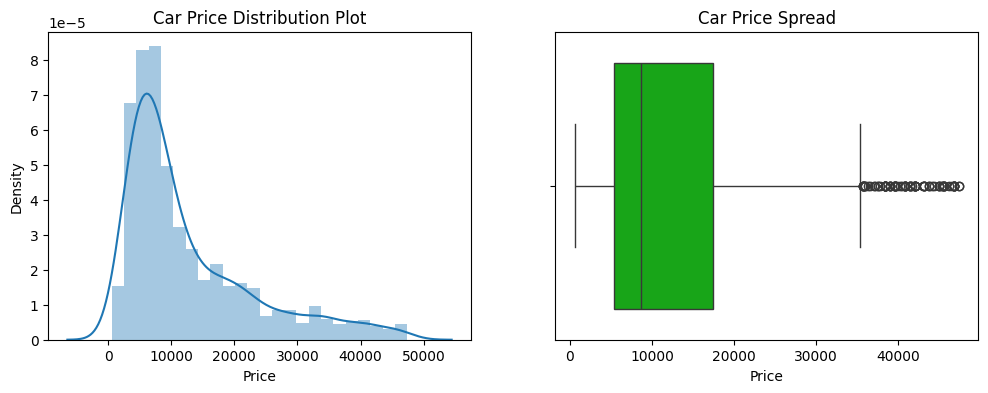

In [28]:
#Histográma y caja de bigotes del precio de los vehículos

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.title('Car Price Distribution Plot')
sns.distplot(d['Price'])

plt.subplot(1,2,2)
plt.title('Car Price Spread')
sns.boxplot(x=d['Price'], palette='nipy_spectral')

plt.show()

In [29]:
#Descripción del precio de los vehículos después de eliminar valores atípicos

print(d['Price'].describe(percentiles = [0.25,0.50,0.75,0.85,0.90,0.95,0.975,1]))

count    1645
mean    12691
std     10298
min       588
25%      5400
50%      8700
75%     17400
85%     23400
90%     28800
95%     35748
97.5%   40800
100%    47400
max     47400
Name: Price, dtype: float64


### Imputaciones

In [30]:
#Identificación de valores nulos para las variables numéricas
for col in d[numCols]:
    print (col, np.sum(pd.isnull(d[col])))

Price 0
Year 0
Kilometer 0
Engine 65
Length 49
Width 49
Height 49
Seating Capacity 49
Fuel Tank Capacity 80


In [31]:
# Registros donde varias características (Length, Length, Height y Seating Capacity) son vacías
d.loc[d['Length'].isna() & d['Width'].isna() & d['Height'].isna() & d['Seating Capacity'].isna()]

,Make,Price,Year,Kilometer,Fuel Type,Transmission,Owner,Seller Type,Engine,Drivetrain,Length,Width,Height,Seating Capacity,Fuel Tank Capacity
3,Volkswagen,4140,2011,50667,Petrol,Automatic,Second,Individual,NaN,NaN,NaN,NaN,NaN,NaN,NaN
23,Volkswagen,3720,2009,107879,Diesel,Manual,Second,Individual,NaN,NaN,NaN,NaN,NaN,NaN,NaN
28,Mercedes-Benz,6120,2007,39000,Petrol,Automatic,Third,Individual,NaN,NaN,NaN,NaN,NaN,NaN,NaN
57,Maruti Suzuki,852,2004,65082,Petrol,Manual,First,Individual,NaN,NaN,NaN,NaN,NaN,NaN,NaN
76,Volkswagen,3300,2011,80000,Petrol,Manual,Second,Individual,NaN,NaN,NaN,NaN,NaN,NaN,NaN
102,Hyundai,2940,2011,41000,Petrol,Manual,First,Individual,NaN,NaN,NaN,NaN,NaN,NaN,NaN
112,Mercedes-Benz,14400,2000,65000,Petrol,Automatic,Second,Individual,NaN,NaN,NaN,NaN,NaN,NaN,NaN
158,Mercedes-Benz,46800,2018,83400,Diesel,Automatic,Second,Individual,NaN,NaN,NaN,NaN,NaN,NaN,NaN
218,Volkswagen,3480,2014,125000,Diesel,Manual,First,Individual,NaN,NaN,NaN,NaN,NaN,NaN,NaN
239,Hyundai,3000,2012,72000,Petrol,Manual,Third,Individual,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [32]:
# Se eliminan aquellas filas donde TODAS estas variables son vacías (NaN) simultáneamente
d = d.dropna(subset=['Length', 'Width', 'Height', 'Seating Capacity'], how='all')

print(f"Filas después de eliminar registros sin datos de dimensiones: {d.shape[0]}")

Filas después de eliminar registros sin datos de dimensiones: 1596


In [33]:
#Identificación de valores nulos para las variables numéricas
for col in d[numCols]:
    print (col, np.sum(pd.isnull(d[col])))

Price 0
Year 0
Kilometer 0
Engine 16
Length 0
Width 0
Height 0
Seating Capacity 0
Fuel Tank Capacity 31


In [34]:
#Imputación de variables numéricas por medio de KNNImputer
#Nota: el imputador se AJUSTA (fit) solo con el conjunto de entrenamiento (d);
#más adelante se reutiliza (sin reajustar) para transformar el conjunto de prueba.

# Se guarda la lista de columnas numéricas usada en el ajuste, para aplicar exactamente las mismas al conjunto de prueba
numCols_impute = numCols.copy()

# crear un objeto KNNImputer con k=5
num_imputer = KNNImputer(n_neighbors=5)

# imputar los valores faltantes en el dataframe de entrenamiento
df_imputed = num_imputer.fit_transform(d[numCols_impute])

# convertir el arreglo numpy devuelto por el imputer en un dataframe, preservando el índice original
df_imputed = pd.DataFrame(df_imputed, columns=numCols_impute, index=d.index)

# imprimir el dataframe con los valores imputados
df_imputed.head()

,Price,Year,Kilometer,Engine,Length,Width,Height,Seating Capacity,Fuel Tank Capacity
0,9300,2020,39000,1197,3995,1775,1505,5,37
1,7500,2019,31000,1197,3985,1734,1505,5,45
2,33600,2018,20000,2143,4630,1777,1432,5,56
4,11940,2016,105000,2179,4585,1890,1785,7,70
5,18240,2021,14000,1997,3985,1820,1844,4,57


In [35]:
#Identificación de valores nulos para las variables categorica
for col in d[catCols]:
    print (col, np.sum(pd.isnull(d[col])))

Make 0
Fuel Type 0
Transmission 0
Owner 0
Seller Type 0
Drivetrain 65


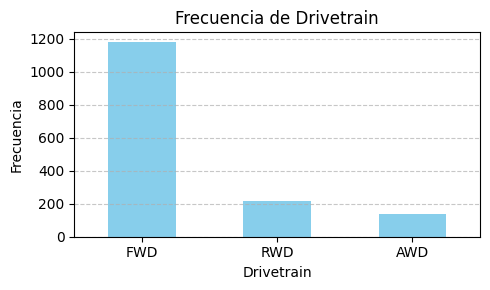

In [36]:
# Graficar la frecuencia de Drivetrain

plt.figure(figsize=(5, 3))
d['Drivetrain'].value_counts().plot(kind='bar', color='skyblue')
plt.title('Frecuencia de Drivetrain')
plt.xlabel('Drivetrain')
plt.ylabel('Frecuencia')
plt.xticks(rotation=0)  # Rotar etiquetas en el eje x
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [37]:
#Imputación de variables categóricas por medio de SimpleImputer
#Nota: al igual que con las variables numéricas, este imputador se ajusta solo con el entrenamiento (d).

# Se guarda la lista de columnas categóricas usada en el ajuste, para aplicar exactamente las mismas al conjunto de prueba
catCols_impute = catCols.copy()

# crear un objeto SimpleImputer con la estrategia de más frecuente
cat_imputer = SimpleImputer(strategy='most_frequent')

# imputar los valores faltantes en el dataframe de entrenamiento
df_imputed2 = cat_imputer.fit_transform(d[catCols_impute])

# convertir el arreglo numpy devuelto por el imputer en un dataframe, preservando el índice original
df_imputed2 = pd.DataFrame(df_imputed2, columns=catCols_impute, index=d.index)

#imprimir el dataframe con los valores imputados
df_imputed2

,Make,Fuel Type,Transmission,Owner,Seller Type,Drivetrain
0,Hyundai,Petrol,Manual,First,Individual,FWD
1,Hyundai,Petrol,Manual,First,Individual,FWD
2,Mercedes-Benz,Diesel,Automatic,First,Individual,FWD
4,Mahindra,Diesel,Automatic,Second,Individual,FWD
5,Mahindra,Petrol,Manual,First,Individual,AWD
...,...,...,...,...,...,...
1640,Volkswagen,Petrol,Automatic,Second,Individual,FWD
1641,Honda,Petrol,Manual,First,Individual,FWD
1642,Maruti Suzuki,Diesel,Manual,First,Individual,FWD
1643,Mahindra,Diesel,Manual,First,Individual,RWD


In [38]:
#Integración de los dos dataframes (categoricos y numéricos) después de la imputación
d = pd.merge(df_imputed, df_imputed2, left_index=True, right_index=True)
d.head()

,Price,Year,Kilometer,Engine,Length,Width,Height,Seating Capacity,Fuel Tank Capacity,Make,Fuel Type,Transmission,Owner,Seller Type,Drivetrain
0,9300,2020,39000,1197,3995,1775,1505,5,37,Hyundai,Petrol,Manual,First,Individual,FWD
1,7500,2019,31000,1197,3985,1734,1505,5,45,Hyundai,Petrol,Manual,First,Individual,FWD
2,33600,2018,20000,2143,4630,1777,1432,5,56,Mercedes-Benz,Diesel,Automatic,First,Individual,FWD
4,11940,2016,105000,2179,4585,1890,1785,7,70,Mahindra,Diesel,Automatic,Second,Individual,FWD
5,18240,2021,14000,1997,3985,1820,1844,4,57,Mahindra,Petrol,Manual,First,Individual,AWD


In [39]:
#verificación de la imputación: No existen valores nulos
for col in d.columns:
    print (col, np.sum(pd.isnull(d[col])))

Price 0
Year 0
Kilometer 0
Engine 0
Length 0
Width 0
Height 0
Seating Capacity 0
Fuel Tank Capacity 0
Make 0
Fuel Type 0
Transmission 0
Owner 0
Seller Type 0
Drivetrain 0


### Valores atípicos para las variables de entrada

In [40]:
#utilización de LocalOutlierFactor con 13 vecinos para identificar valores atípicos en las variables de entrada


# crear un objeto LocalOutlierFactor con n_neighbors=13
lof = LocalOutlierFactor(n_neighbors=13, contamination=0.1)

# identificar los valores atípicos por medio de lof
y_pred = lof.fit_predict(d[numCols])

# Identificar los índices de los valores atípicos
outliers = y_pred == -1

print('Indices de valores atípicos: ', d[outliers].index.tolist())


Indices de valores atípicos:  [4, 52, 58, 68, 77, 99, 138, 143, 157, 163, 165, 168, 171, 182, 204, 211, 217, 221, 224, 241, 246, 253, 257, 265, 281, 289, 296, 334, 335, 366, 378, 379, 382, 397, 410, 414, 436, 471, 478, 487, 499, 514, 527, 541, 564, 574, 582, 585, 586, 609, 615, 620, 627, 629, 642, 644, 660, 669, 673, 674, 676, 680, 683, 685, 686, 688, 690, 726, 727, 745, 747, 748, 756, 758, 765, 783, 792, 800, 804, 807, 848, 882, 888, 897, 913, 920, 943, 955, 977, 1013, 1016, 1039, 1057, 1064, 1065, 1081, 1085, 1087, 1094, 1097, 1125, 1137, 1139, 1152, 1156, 1159, 1169, 1176, 1193, 1197, 1210, 1211, 1219, 1221, 1238, 1244, 1254, 1265, 1276, 1280, 1289, 1294, 1303, 1345, 1351, 1358, 1360, 1361, 1389, 1404, 1408, 1411, 1416, 1427, 1434, 1444, 1462, 1467, 1477, 1490, 1493, 1494, 1501, 1504, 1505, 1517, 1518, 1524, 1539, 1567, 1571, 1573, 1574, 1575, 1577, 1594, 1603, 1624, 1629, 1644]


In [41]:
# Eliminar los valores atípicos del dataframe original
d = d.loc[~outliers].reset_index(drop=True)

print(f"Filas después de eliminar atípicos de las variables de entrada (LOF): {d.shape[0]}")

Filas después de eliminar atípicos de las variables de entrada (LOF): 1436


### Transformaciones

In [42]:
#Eliminación de categorias pequeñas para la variable Fuel Type

d['Fuel Type'].value_counts().sort_values(ascending=False)

,count
Fuel Type,
Petrol,695
Diesel,685
CNG,46
Electric,6
LPG,2
Petrol + CNG,1
CNG + CNG,1


In [43]:
#Diccionario con los reemplazos a realizar
reemplazos = { "CNG": "Otro"
              ,"Electric": "Otro"
              , "LPG": "Otro"
              , "CNG + CNG": "Otro"
              , "Petrol + CNG": "Otro"
              , "Petrol + LPG": "Otro"}


#Se reemplazan los valores de acuerdo con el diccionario creado anteriormente
d['Fuel Type'] = d['Fuel Type'].map(reemplazos).fillna(d['Fuel Type'])

#Visualización de las nuevos valores agrupados para la categoria 'Fuel Type'
d['Fuel Type'].value_counts().sort_values(ascending=False)

,count
Fuel Type,
Petrol,695
Diesel,685
Otro,56


In [44]:
#Discretización (binning) de la variable 'Make'

#Cantidad de instancias por Make
d['Make'].value_counts().sort_values(ascending=False)

,count
Make,
Maruti Suzuki,373
Hyundai,289
Honda,126
Toyota,97
Mahindra,92
Audi,75
Mercedes-Benz,62
Tata,48
BMW,45


In [45]:
#Se Calcula la mediana por marca 'Make'

d.groupby('Make').Price.median().sort_values(ascending=False)

,Price
Make,
Land Rover,41400
Jaguar,38694
MINI,38400
BMW,31800
Audi,26160
Isuzu,25200
Mercedes-Benz,24864
MG,22590
Jeep,20988


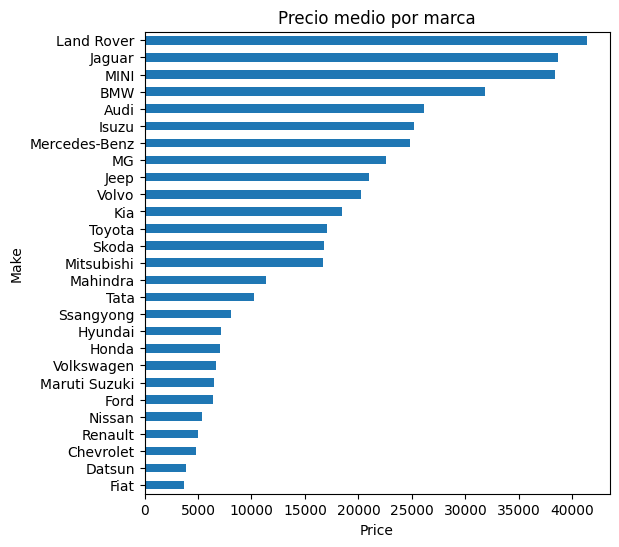

In [46]:
#Gráfica de visualización de precio medio por marca 'Make'
plt.figure(figsize=(6, 6))

d.groupby('Make').Price.median().sort_values(ascending=True).plot.barh()
plt.title("Precio medio por marca")
plt.ylabel("Make")
plt.xlabel("Price")
plt.show()

In [47]:
df= d.groupby('Make').Price.median().sort_values(ascending=False)
df=df.reset_index()
df.head(10)

,Make,Price
0,Land Rover,41400
1,Jaguar,38694
2,MINI,38400
3,BMW,31800
4,Audi,26160
5,Isuzu,25200
6,Mercedes-Benz,24864
7,MG,22590
8,Jeep,20988
9,Volvo,20280


In [48]:
#Se crea una nueva variable que agrupa el precio medio por marca en bins (categorías ordinales)
#Nota: 'df' aquí se calcula usando solo el conjunto de entrenamiento (ver sección de separación de datos),
#por lo que este binning no incorpora información del conjunto de prueba.

#Configuración de formato de visualización
pd.set_option('display.float_format', lambda x: '%.4f' % x)

#Se define el numero de bins que se quieren crear
numBins = 5

#Se usa pd.cut para crear bins de ancho igual entre el mínimo y el máximo precio medio
#(evita el error de "off-by-one" de calcular el bin manualmente con round())
df['PriceRange'] = pd.cut(df['Price'], bins=numBins, labels=False)

df

,Make,Price,PriceRange
0,Land Rover,41400.0000,4
1,Jaguar,38694.0000,4
2,MINI,38400.0000,4
3,BMW,31800.0000,3
4,Audi,26160.0000,2
5,Isuzu,25200.0000,2
6,Mercedes-Benz,24863.9940,2
7,MG,22589.9940,2
8,Jeep,20987.9880,2
9,Volvo,20279.9880,2


In [49]:
#Se adiciona la nueva variable al dataset original
d=pd.merge(d, df[['Make','PriceRange']], on='Make', how='left')

#Se elimina la variable Make
d = d.drop(['Make'], axis=1)

d.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Price               1436 non-null   float64
 1   Year                1436 non-null   float64
 2   Kilometer           1436 non-null   float64
 3   Engine              1436 non-null   float64
 4   Length              1436 non-null   float64
 5   Width               1436 non-null   float64
 6   Height              1436 non-null   float64
 7   Seating Capacity    1436 non-null   float64
 8   Fuel Tank Capacity  1436 non-null   float64
 9   Fuel Type           1436 non-null   object 
 10  Transmission        1436 non-null   object 
 11  Owner               1436 non-null   object 
 12  Seller Type         1436 non-null   object 
 13  Drivetrain          1436 non-null   object 
 14  PriceRange          1436 non-null   int64  
dtypes: float64(9), int64(1), object(5)
memory usage: 168.4+

In [50]:
numCols.append('PriceRange')
numCols

['Price',
 'Year',
 'Kilometer',
 'Engine',
 'Length',
 'Width',
 'Height',
 'Seating Capacity',
 'Fuel Tank Capacity',
 'PriceRange']

In [51]:
catCols.remove('Make')
catCols

['Fuel Type', 'Transmission', 'Owner', 'Seller Type', 'Drivetrain']

## 8. Preparar el conjunto de prueba

El conjunto de prueba (`d_test`) se apartó en la sección 5, antes de cualquier ajuste estadístico. Ahora se le aplican las **mismas transformaciones ya ajustadas sobre el entrenamiento** (imputadores, agrupación de categorías, codificación de `PriceRange`) — nunca se vuelve a ajustar nada con estos datos.

Nótese que **no** se le aplica eliminación de valores atípicos (ni en `Price` ni mediante LOF): en un escenario real no se pueden descartar solicitudes de predicción solo porque "se ven raras"; el modelo debe intentar predecir sobre ellas igualmente.

In [52]:
# Se aplica al conjunto de prueba la MISMA agrupación de categorías definida sobre el entrenamiento
d_test['Fuel Type'] = d_test['Fuel Type'].map(reemplazos).fillna(d_test['Fuel Type'])

In [53]:
# Se imputan los valores numéricos faltantes del conjunto de prueba
# usando el MISMO imputador (num_imputer) ya ajustado sobre el entrenamiento (nunca se reajusta con datos de prueba)
d_test_num = pd.DataFrame(
    num_imputer.transform(d_test[numCols_impute]),
    columns=numCols_impute,
    index=d_test.index
)
d_test[numCols_impute] = d_test_num

In [54]:
# Se imputan los valores categóricos faltantes del conjunto de prueba
# usando el MISMO imputador (cat_imputer) ya ajustado sobre el entrenamiento
d_test_cat = pd.DataFrame(
    cat_imputer.transform(d_test[catCols_impute]),
    columns=catCols_impute,
    index=d_test.index
)
d_test[catCols_impute] = d_test_cat

In [55]:
# Se asigna PriceRange usando la tabla de medianas por marca calculada SOLO con el entrenamiento (df)
d_test = pd.merge(d_test, df[['Make', 'PriceRange']], on='Make', how='left')

# Si en prueba aparece una marca (Make) que no existía en entrenamiento, se asigna el bin mediano como valor por defecto
fallback_bin = int(df['PriceRange'].median())
d_test['PriceRange'] = d_test['PriceRange'].fillna(fallback_bin).astype(int)

# Se elimina la variable Make, igual que se hizo en el conjunto de entrenamiento
d_test = d_test.drop(['Make'], axis=1)

In [56]:
# Se dejan los nombres 'df' (entrenamiento) y 'dp' (prueba) para mantener consistencia con la sección de exportación
df = d
dp = d_test[df.columns]  # se asegura el mismo orden de columnas que en entrenamiento

print(f"Filas de entrenamiento (df): {df.shape[0]}")
print(f"Filas de prueba (dp): {dp.shape[0]}")

Filas de entrenamiento (df): 1436
Filas de prueba (dp): 206


## 9. Exportar el dataset

Se exportan `df` (entrenamiento, completamente preparado) y `dp` (prueba, transformado usando los parámetros ya ajustados sobre el entrenamiento).

In [57]:
# Exportamos el dataframe a un archivo CSV
df.to_csv(DATASETS_PATH + '01_carDetailsV4_Prep.csv', index=False)
dp.to_csv(DATASETS_PATH + '01_carDetailsV4_Prue.csv', index=False)

In [58]:
df.head(10)

,Price,Year,Kilometer,Engine,Length,Width,Height,Seating Capacity,Fuel Tank Capacity,Fuel Type,Transmission,Owner,Seller Type,Drivetrain,PriceRange
0,9300.0000,2020.0000,39000.0000,1197.0000,3995.0000,1775.0000,1505.0000,5.0000,37.0000,Petrol,Manual,First,Individual,FWD,0
1,7500.0000,2019.0000,31000.0000,1197.0000,3985.0000,1734.0000,1505.0000,5.0000,45.0000,Petrol,Manual,First,Individual,FWD,0
2,33600.0000,2018.0000,20000.0000,2143.0000,4630.0000,1777.0000,1432.0000,5.0000,56.0000,Diesel,Automatic,First,Individual,FWD,2
3,18240.0000,2021.0000,14000.0000,1997.0000,3985.0000,1820.0000,1844.0000,4.0000,57.0000,Petrol,Manual,First,Individual,AWD,1
4,10788.0000,2018.0000,13066.0000,1373.0000,4490.0000,1730.0000,1485.0000,5.0000,43.0000,Petrol,Manual,First,Individual,FWD,0
5,7860.0000,2016.0000,38779.0000,1197.0000,3995.0000,1745.0000,1500.0000,5.0000,37.0000,Petrol,Manual,First,Individual,FWD,0
6,19800.0000,2014.0000,53089.0000,1796.0000,4868.0000,1854.0000,1470.0000,5.0000,80.0000,Petrol,Automatic,Second,Individual,RWD,2
7,10500.0000,2015.0000,67000.0000,2179.0000,4456.0000,1820.0000,1995.0000,8.0000,60.0000,Diesel,Manual,First,Individual,RWD,1
8,3000.0000,2011.0000,64000.0000,1197.0000,3585.0000,1595.0000,1550.0000,5.0000,35.0000,Petrol,Manual,First,Individual,FWD,0
9,5100.0000,2014.0000,74000.0000,1461.0000,4331.0000,1822.0000,1671.0000,5.0000,50.0000,Diesel,Manual,Second,Individual,FWD,0


### Referencias


- *Dataset:*  
    - https://www.kaggle.com/datasets/nehalbirla/vehicle-dataset-from-cardekho?select=car+details+v4.csv
    
    
- *Machine learning con Python y Scikit-learn:*
    - https://www.cienciadedatos.net/documentos/py06_machine_learning_python_scikitlearn.html
    
    
- *LocalOutlierFactor:*
    - https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.LocalOutlierFactor.html
    

- *scikit-learn:*    
    - https://scikit-learn.org/stable/
    - https://scikit-learn.org/stable/user_guide.html
  
  
- *Gráficas con  seaborn:*
    - https://ichi.pro/es/como-utilizar-python-seaborn-para-analisis-de-datos-exploratorios-28897898172180

  